# Chapter 14 Deep Computer Vision Using Convolutional Neural Networks

## 14.1 The Architecture of the Visual Cortex

## 14.2 Convolutional Layers

********************************************
china.jpg
Data type:  uint8
Data shape:  (427, 640, 3)


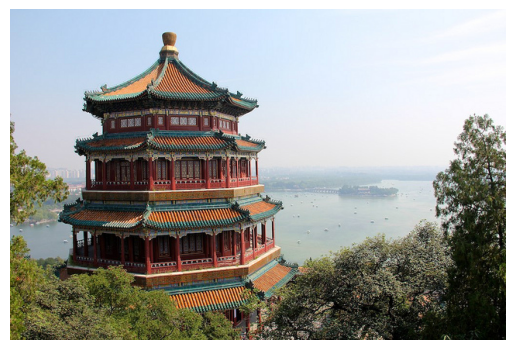

********************************************
flower.jpg
Data type:  uint8
Data shape:  (427, 640, 3)


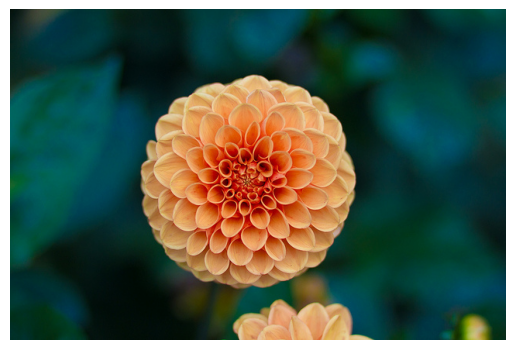

In [1]:
# Original images
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_sample_image

def plot_image(image: np.ndarray):
    fig, ax = plt.subplots()
    ax.imshow(image)
    ax.axis("off")
    plt.show()

image_names = ["china.jpg", "flower.jpg"]
images = np.array([load_sample_image(name) for name in image_names])
images_in = images / 255

for image_name, image in zip(image_names, images):
    print("********************************************")
    print(image_name)
    print("Data type: ", image.dtype)
    print("Data shape: ", image.shape)
    plot_image(image)

2022-11-08 14:12:15.342962: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2022-11-08 14:12:17.382653: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-11-08 14:12:17.443344: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-11-08 14:12:17.443718: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so retur

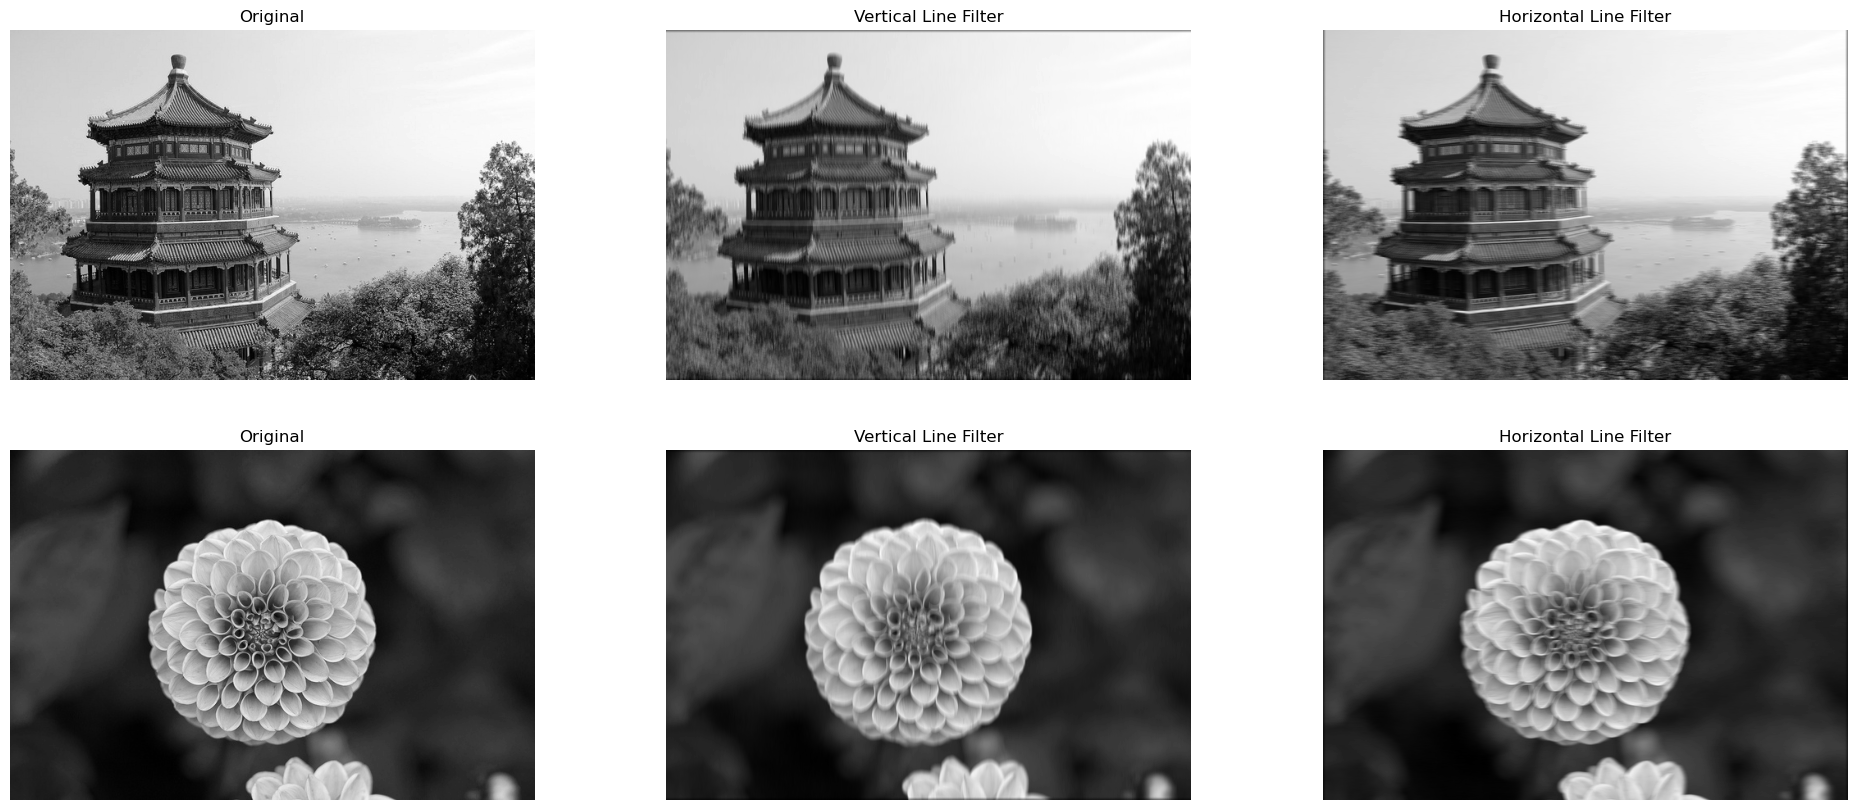

In [2]:
# Filters
import tensorflow as tf
from PIL import Image
from typing import List, Optional

height, weight, n_channels = images[0].shape
filters = np.zeros(shape=(7, 7, n_channels, 2), dtype=np.float32)
filters[:, 3, :, 0] = 1
filters[3, :, :, 1] = 1
images_conv2d = tf.nn.conv2d(input=images_in, filters=filters, strides=1, padding="SAME")

def plot_feature_maps(images_org: np.ndarray, images_out: np.ndarray, feature_map_names: Optional[List[str]] = None):
    n_images, height, width, n_feature_maps = images_out.shape
    fig, axs = plt.subplots(n_images, 1 + n_feature_maps, figsize=(24, 5 * n_images), squeeze=False)
    for axs_row, image_org, image_out in zip(axs, images_org, images_out):
        axs_row[0].imshow(Image.fromarray(image_org).convert("L"), cmap="gray")
        axs_row[0].axis("off")
        axs_row[0].set_title("Original")

        if feature_map_names is None:
            feature_map_names = [f"Feature Map {i_feature_map}" for i_feature_map in range(n_feature_maps)]

        for i_feature_map, (ax, feature_map_name) in enumerate(zip(axs_row[1:], feature_map_names)):
            ax.imshow(image_out[:, :, i_feature_map], cmap="gray")
            ax.axis("off")
            ax.set_title(feature_map_name)

feature_map_names = ["Vertical Line Filter", "Horizontal Line Filter"]
plot_feature_maps(images, images_conv2d, feature_map_names)

In [3]:
# Conv Layer
conv = tf.keras.layers.Conv2D(filters=32, kernel_size=(3, 3), strides=1, padding="same", activation="selu", kernel_initializer="lecun_normal")
conv

## 14.3 Pooling Layers

##### General Pooling Layer

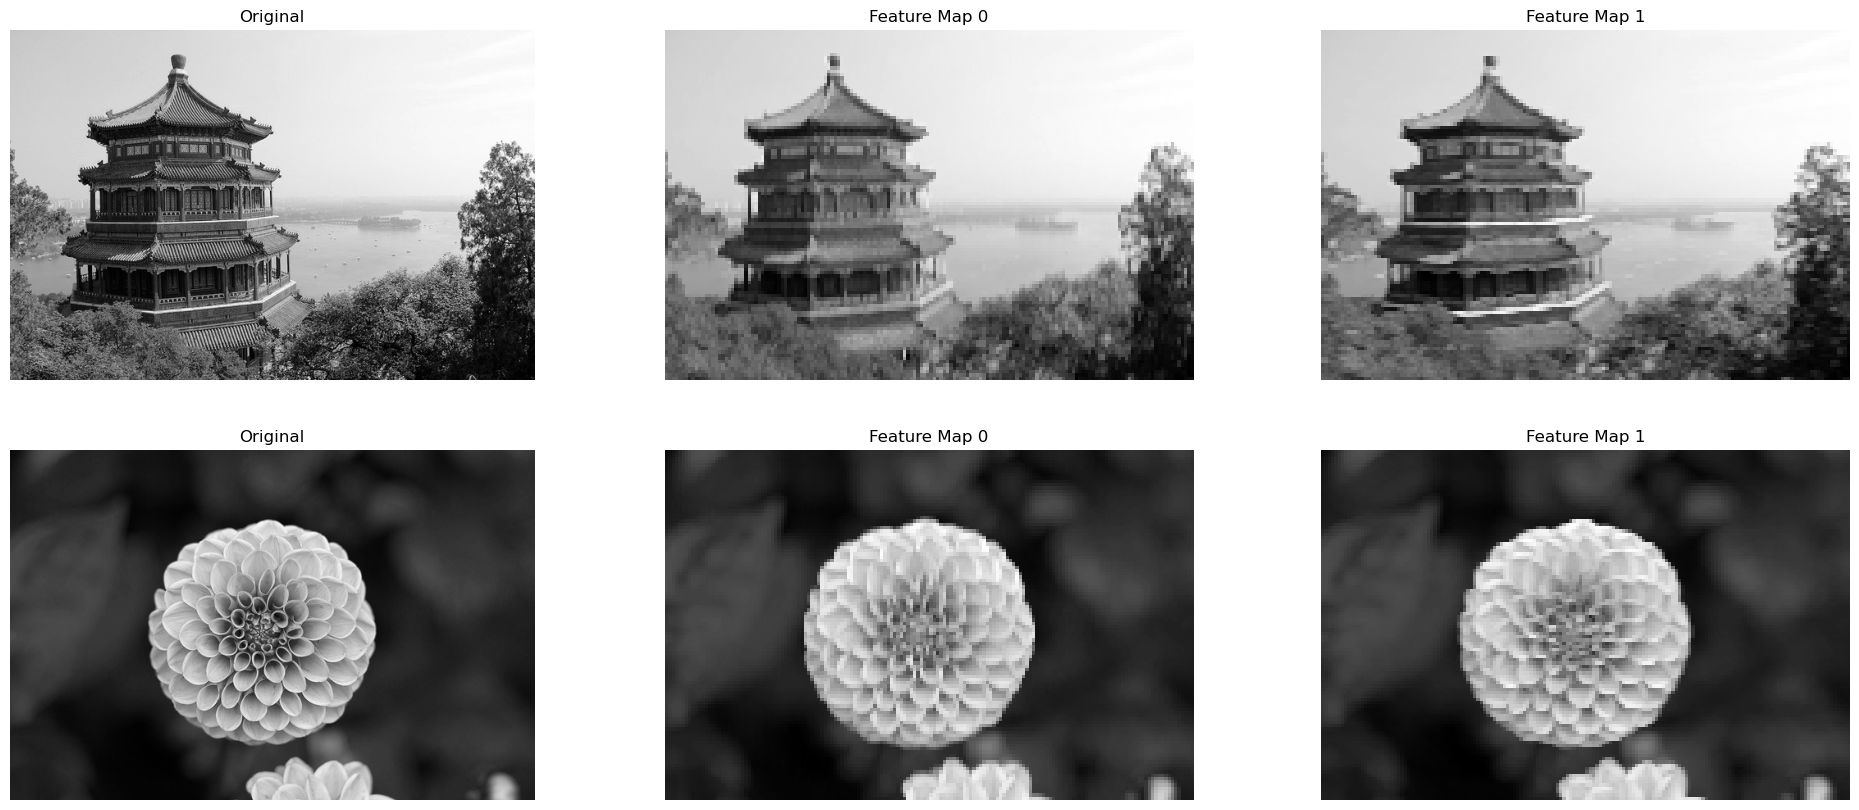

In [4]:
max_pool = tf.keras.layers.MaxPool2D(pool_size=4)
plot_feature_maps(images, max_pool(images_conv2d))

##### Depthwise Max Pooling
Depthwise max pooling is currently only implemented for CPU devices.

In [5]:
# plot_feature_maps(images, tf.nn.max_pool(images_conv2d, ksize=(1, 1, 1, 2), strides=(1, 1, 1, 2), padding="VALID"))

##### Global Average Pooling

In [6]:
global_avg_pool = tf.keras.layers.GlobalAvgPool2D()

global_avg_pool(images_in)

<tf.Tensor: shape=(2, 3), dtype=float32, numpy=
array([[0.5675281 , 0.57046425, 0.552622  ],
       [0.21621236, 0.2885447 , 0.22353025]], dtype=float32)>

In [7]:
global_avg_pool_eq = lambda X: tf.reduce_mean(X, axis=[1, 2])
global_avg_pool_eq(images_in)

<tf.Tensor: shape=(2, 3), dtype=float64, numpy=
array([[0.56752817, 0.57046428, 0.55262199],
       [0.21621236, 0.28854471, 0.22353024]])>

## 14.4 CNN Architectures

In [8]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.datasets import fashion_mnist

label_names = np.array(["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"])

(X_train_orig_full, y_train_full), (X_test_orig, y_test) = fashion_mnist.load_data()

X_train_full_norm = X_train_orig_full / 255
X_test = X_test_orig / 255

X_train, X_valid, y_train, y_valid = train_test_split(X_train_full_norm, y_train_full, test_size=0.2, random_state=42)

print("X_train_orig_full: ", X_train_orig_full.shape)
print("y_train_full: ", y_train_full.shape)
print("X_test_orig: ", X_test_orig.shape)
print("y_test: ", y_test.shape)

X_train_orig_full:  (60000, 28, 28)
y_train_full:  (60000,)
X_test_orig:  (10000, 28, 28)
y_test:  (10000,)


/tmp/ipykernel_5843/1721305810.py:14: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


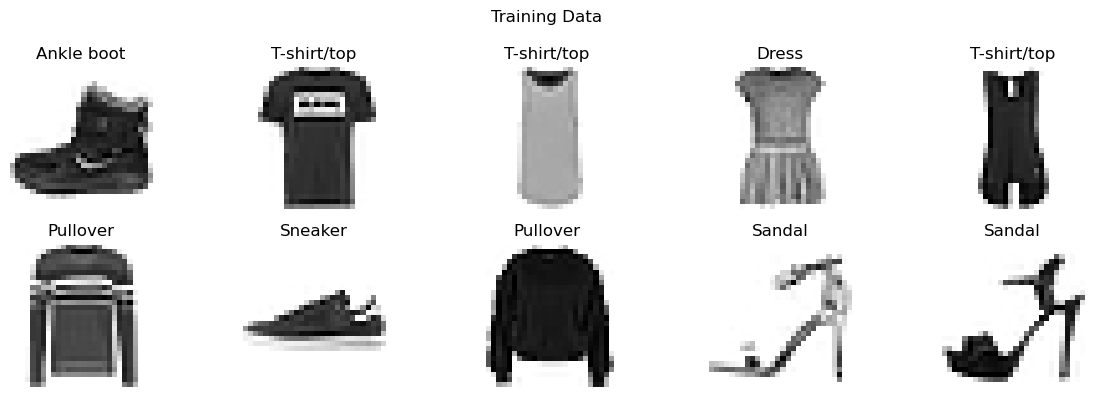

In [9]:
from typing import Sequence

def plot_images(images: Sequence[np.ndarray], labels: Sequence[str], fig_title: str = None) -> None:
    n_cols = 5
    n_rows = int(np.ceil(len(images) / n_cols))
    fig, axs = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(12, n_rows * 2))
    for ax, image, label in zip(axs.ravel(), images, labels):
        ax.imshow(image, cmap="gray_r")
        ax.axis("off")
        ax.set_title(label)
    if fig_title is not None:
        fig.suptitle(fig_title)
    fig.tight_layout()
    fig.show()

plot_images(X_train_orig_full[:10], label_names[y_train_full[:10]], "Training Data")

In [10]:
model_1 = "?"

In [11]:
model_2 = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(64, 7, padding="same", activation="relu", input_shape=(28, 28, 1)),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Conv2D(128, 3, padding="same", activation="relu"),
    tf.keras.layers.Conv2D(128, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Conv2D(256, 3, padding="same", activation="relu"),
    tf.keras.layers.Conv2D(256, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(10, activation="softmax"),
])

In [12]:
model_3 = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(64, 7, padding="same", activation="selu", kernel_initializer="lecun_normal", input_shape=(28, 28, 1)),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Conv2D(128, 3, padding="same", activation="selu", kernel_initializer="lecun_normal"),
    tf.keras.layers.Conv2D(128, 3, padding="same", activation="selu", kernel_initializer="lecun_normal"),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Conv2D(256, 3, padding="same", activation="selu", kernel_initializer="lecun_normal"),
    tf.keras.layers.Conv2D(256, 3, padding="same", activation="selu", kernel_initializer="lecun_normal"),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="selu", kernel_initializer="lecun_normal"),
    tf.keras.layers.AlphaDropout(0.5),
    tf.keras.layers.Dense(64, activation="selu", kernel_initializer="lecun_normal"),
    tf.keras.layers.AlphaDropout(0.5),
    tf.keras.layers.Dense(10, activation="softmax"),
])

model_3.compile(optimizer="adam", loss=tf.keras.losses.SparseCategoricalCrossentropy(), metrics=["accuracy"])
model_3.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_6 (Conv2D)           (None, 28, 28, 64)        3200      
                                                                 
 max_pooling2d_4 (MaxPooling  (None, 14, 14, 64)       0         
 2D)                                                             
                                                                 
 conv2d_7 (Conv2D)           (None, 14, 14, 128)       73856     
                                                                 
 conv2d_8 (Conv2D)           (None, 14, 14, 128)       147584    
                                                                 
 max_pooling2d_5 (MaxPooling  (None, 7, 7, 128)        0         
 2D)                                                             
                                                                 
 conv2d_9 (Conv2D)           (None, 7, 7, 256)        

In [13]:
model = model_3

In [14]:
import time
from pathlib import Path

run_id = time.strftime("run_%Y_%m_%d-%H_%M_%S")
dir_log = Path("tensorboard_logs", run_id)
dir_log

PosixPath('tensorboard_logs/run_2022_11_08-14_12_24')

In [15]:
%load_ext tensorboard
%tensorboard --logdir=./tensorboard_logs --port 6006

Launching TensorBoard...

In [16]:
early_stopping_cg = tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)
tensorboard_cb = tf.keras.callbacks.TensorBoard(dir_log)
history = model.fit(X_train, y_train, validation_data=(X_valid, y_valid), epochs=100, callbacks=[early_stopping_cg, tensorboard_cb])

Epoch 1/100
1500/1500 [==============================] - 32s 20ms/step - loss: 0.8289 - accuracy: 0.7061 - val_loss: 0.8596 - val_accuracy: 0.8285
Epoch 2/100
1500/1500 [==============================] - 37s 25ms/step - loss: 0.7788 - accuracy: 0.7806 - val_loss: 0.9482 - val_accuracy: 0.7955
Epoch 3/100
1500/1500 [==============================] - 41s 27ms/step - loss: 0.5535 - accuracy: 0.8057 - val_loss: 1.1700 - val_accuracy: 0.7587
Epoch 4/100
1500/1500 [==============================] - 51s 34ms/step - loss: 0.5634 - accuracy: 0.8089 - val_loss: 0.7302 - val_accuracy: 0.8564
Epoch 5/100
1500/1500 [==============================] - 51s 34ms/step - loss: 0.4677 - accuracy: 0.8376 - val_loss: 0.8674 - val_accuracy: 0.8632
Epoch 6/100
1500/1500 [==============================] - 45s 30ms/step - loss: 0.4670 - accuracy: 0.8402 - val_loss: 0.9415 - val_accuracy: 0.8512
Epoch 7/100
1500/1500 [==============================] - 45s 30ms/step - loss: 0.4504 - accuracy: 0.8439 - val_loss: 0

In [17]:
score = model.evaluate(X_test, y_test)
print(f"Test loss: {score[0]} / Test accuracy: {score[1]}")

313/313 [==============================] - 3s 9ms/step - loss: 0.6830 - accuracy: 0.8663
Test loss: 0.6830065846443176 / Test accuracy: 0.8662999868392944


In [18]:
y_pred = np.argmax(model.predict(X_test), axis=1)

313/313 [==============================] - 2s 7ms/step


/tmp/ipykernel_5843/1721305810.py:14: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


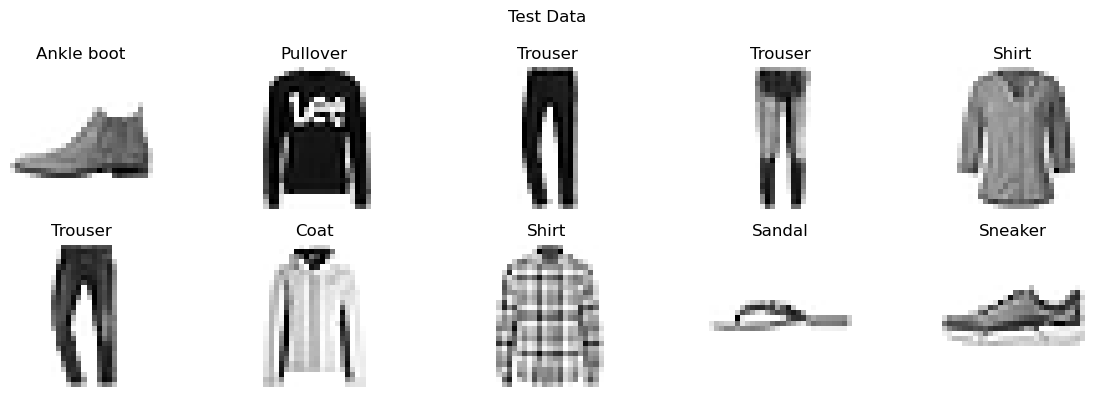

In [19]:
plot_images(X_test_orig[:10], label_names[y_pred[:10]], "Test Data")